<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjoshuaw/weeks/week_01/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [4]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [5]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_345/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_345/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


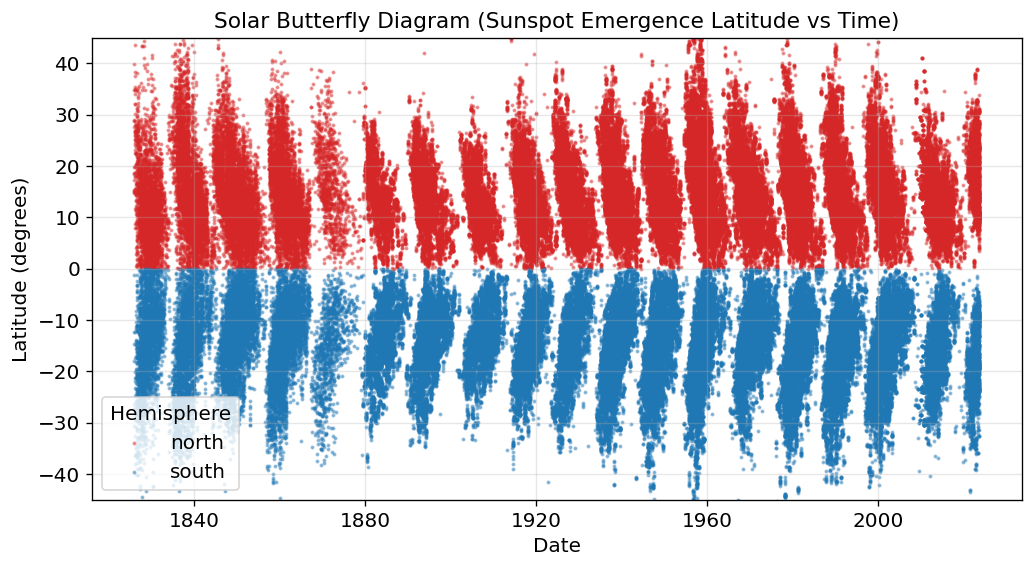

In [6]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


In [8]:
cycle_num = 24
df_cycle = df[df["CYCLE"] == cycle_num]

/tmp/ipykernel_345/3100664454.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cycle["hemisphere"] = df_cycle["latitude"].apply(lambda v: "north" if v >= 0 else "south")


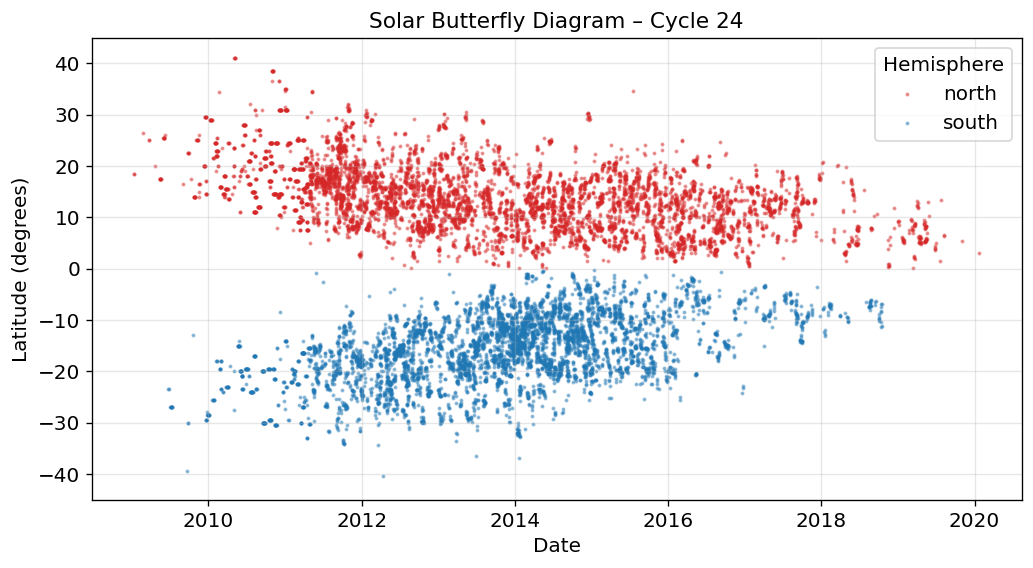

In [10]:
import matplotlib.pyplot as plt

cycle_num = 24
df_cycle = df[df["CYCLE"] == cycle_num]

df_cycle["hemisphere"] = df_cycle["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title(f"Solar Butterfly Diagram – Cycle {cycle_num}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)

plt.show()



## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


In [11]:
df["date"] = pd.to_datetime(df["date"])
df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")

df = df.set_index("date")

In [12]:
mean_lat = (
    df.groupby("hemisphere")
      .resample("M")["latitude"]
      .mean()
      .reset_index()
)

/tmp/ipykernel_345/4072165945.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["latitude"]


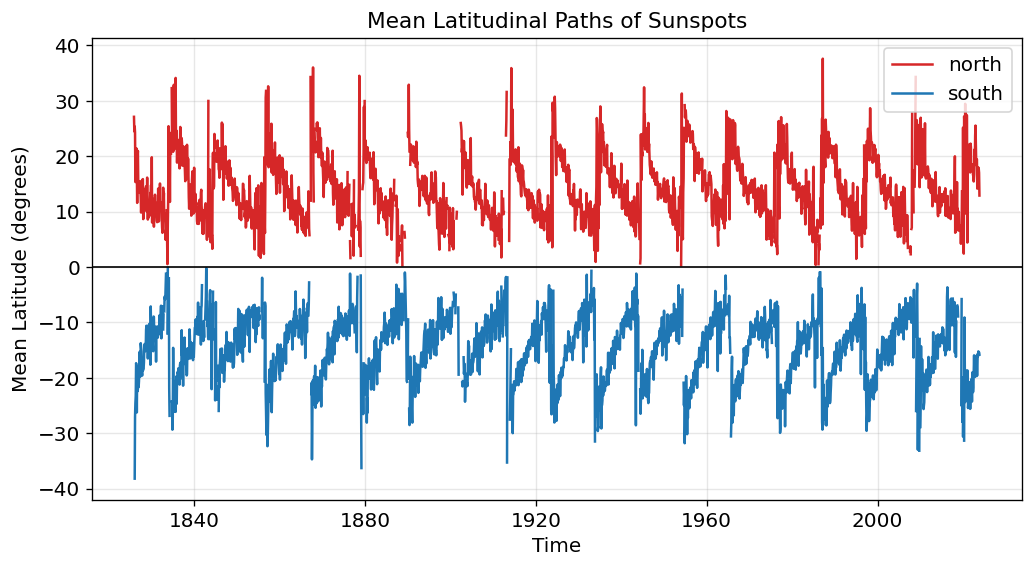

In [13]:
import matplotlib.pyplot as plt

colors = {"north": "tab:red", "south": "tab:blue"}

plt.figure(figsize=(10,5))

for hemi in ["north", "south"]:
    data = mean_lat[mean_lat["hemisphere"] == hemi]
    plt.plot(data["date"], data["latitude"],
             color=colors[hemi], label=hemi)

plt.axhline(0, color="black", linewidth=1)

plt.title("Mean Latitudinal Paths of Sunspots")
plt.xlabel("Time")
plt.ylabel("Mean Latitude (degrees)")
plt.legend()

plt.show()

Looking at the graph, it can be clearly seen that the solar cycle's evolution is cyclic and consistently repeats in a uniform manner. From ChatGPT: "The solar cycle is a systematic, equatorward migration of magnetic activity, governed by the Sun’s internal dynamo."

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


Gemnini's Response:

That's a great question! To effectively use an AI assistant for learning complex topics like machine learning and solar physics, consider the following strategies:

Be Specific and Clear: Instead of broad questions like "Tell me about ML", try "Explain the concept of gradient descent in machine learning, and provide a Python code example using a simple linear regression model." or "What are the different types of sunspots, and how do they relate to the solar cycle?"

Break Down Complex Topics: For very large topics, ask about sub-topics incrementally. For example, in solar physics, you might start with "What is the solar interior composed of?" then follow up with "Now, explain nuclear fusion in the sun's core."

Specify the Level of Detail/Complexity: Tell the AI if you need a high-level overview, a detailed explanation, or an explanation suitable for a beginner/expert. Examples: "Explain this concept as if I'm a high school student," or "Provide an in-depth explanation suitable for a graduate student."

Request Analogies or Examples: Abstract concepts become much clearer with concrete examples. Ask for analogies or real-world applications. "Can you give me an analogy for how a neural network learns?" or "What are some real-world applications of machine learning in astronomy?"

Ask for Code Examples (for ML): For machine learning, requesting code snippets in a specific language (e.g., Python with scikit-learn or TensorFlow) can be very helpful for hands-on learning. "Show me a Python example of how to implement a K-Means clustering algorithm."

Iterate and Follow Up: Don't be afraid to ask follow-up questions. If an explanation is unclear, ask for clarification. "Can you elaborate on the 'loss function' part?" or "How does that relate to solar flares?"

Define Your Goal: Let the AI know what you're trying to achieve. "I'm trying to understand the different types of solar activity for a project; can you help me categorize them and explain their characteristics?" or "I'm building a predictive model for time series data; what ML algorithms are best suited for this, and why?"

Request Summaries or Key Takeaways: After a long explanation, ask for a summary to reinforce your understanding. "Can you summarize the main points about the solar dynamo theory?"

Ask for Practice Problems or Quizzes: Some AIs can generate simple practice questions to test your understanding. "Give me a short quiz on the basics of supervised learning."

By being explicit about your needs and guiding the conversation, you'll get much more targeted and helpful responses, making your learning process more efficient and effective. I'm here to help you apply this advice in future notebooks!


My own reflection:

I plan on applying this advice in future notebooks by asking an AI assistant more specific questions instead of more broader questions in order to enhance my learning.